# CIBUSmod Scenario example:<br/>Revisiting scenarios for organic farming in Sweden

This notebook provides an example run of CIBUSmod using two scenarios up until 2050; 'Base20' and 'Sust50' originally developed by Basnet *et al.* (2023).

**Base20:** A business-as-ususal scenario with assumptions on productivity improvements and population growth   
**Sust50:** A scenario with increased organic production (up to 50% of cropland) coupled with stronger productivity gains, reduced food waste and dietary changes towards less animal-source foods


Basnet, S., Wood, A., Röös, E., Jansson, T., Fetzer, I. & Gordon, L. (2023). Organic agriculture in a low-emission world: exploring combined measures to deliver a sustainable food system in Sweden. *Sustainability Science*, 18(1), 501-519. https://doi.org/10.1007/s11625-022-01279-9

## Set things up

Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Instantiate a `Session` object and define scenarios.

In [3]:
years = list(range(2020,2050+1,5))

# Create session
session = cm.Session(
    name = 'example_scenarios',
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'Base20',
    scenario_workbooks = 'example_bau',
    years = years
)

# Define scenarios
session.add_scenario(
    name = 'Sust50',
    scenario_workbooks = ['example_bau', 'example_org_circ'],
    years = years
)

A scenario with the name 'Base20' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'Sust50' already exists use .update_scenario() or .remove_scenario() instead.


Define some styling for plots

In [4]:
bar_style = {
    'ticklabels_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ylabel_fontsize' : 10,
    'xlabel_fontsize' : 10,
    'cmap' : 'YlGnBu'
}

def annotate_axs(axs, size=10, offset=(-3,1)):
    import string
    for i, ax in enumerate(axs.flatten()):
        ax.annotate(
            f'({string.ascii_lowercase[i % 26]})',
            xy = (0,1), xycoords = 'axes fraction',
            xytext = offset, textcoords = 'offset fontsize',
            fontsize=size, fontweight='bold', va='bottom', ha='right'
        )

## Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [ ]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run
import traceback

# Create list of scenarios/years to run
runs = [(s,y) for s, y in session.iterate('all')]
runs

In [ ]:
%%time

# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, session, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            
            print(f'{scn}, {year} finished successfully in {m}min {s}s')

session.cache.clear()

## Plot output

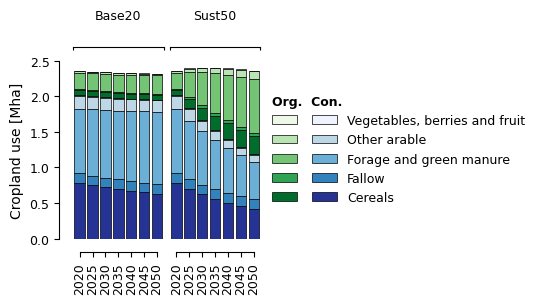

Share of cropland:


prod_system  conventional    organic  total
scn    year                                
Base20 2020     85.588196  14.411804  100.0
       2025     85.306897  14.693103  100.0
       2030     85.049972  14.950028  100.0
       2035     84.817982  15.182018  100.0
       2040     84.594179  15.405821  100.0
       2045     84.372993  15.627007  100.0
       2050     84.170901  15.829099  100.0
Sust50 2020     85.588196  14.411804  100.0
       2025     76.592605  23.407395  100.0
       2030     69.425812  30.574188  100.0
       2035     63.398136  36.601864  100.0
       2040     58.284818  41.715182  100.0
       2045     53.898409  46.101591  100.0
       2050     50.078559  49.921441  100.0

Total cropland area:


prod_system  conventional   organic     total
scn    year                                  
Base20 2020      2.014583  0.339226  2.353809
       2025      2.001139  0.344673  2.345812
       2030      1.988306  0.349503  2.337809
       2035      1.975219  0.353555  2.328774
       2040      1.965521  0.357950  2.323471
       2045      1.958423  0.362726  2.321150
       2050      1.950590  0.366826  2.317416
Sust50 2020      2.014583  0.339226  2.353809
       2025      1.830138  0.559307  2.389445
       2030      1.667401  0.734301  2.401702
       2035      1.522337  0.878896  2.401234
       2040      1.395556  0.998817  2.394373
       2045      1.283716  1.098016  2.381732
       2050      1.182314  1.178604  2.360918

Share "Forage and green manure":


prod_system  conventional    organic
scn    year                         
Base20 2020     45.270935  66.494701
       2025     46.549259  67.132009
       2030     47.746214  67.722952
       2035     48.880969  68.270438
       2040     49.959629  68.792119
       2045     50.994506  69.304970
       2050     51.968523  69.783034
Sust50 2020     45.270935  66.494701
       2025     45.175278  63.583550
       2030     45.102049  63.417024
       2035     45.006864  63.586427
       2040     44.942945  63.849166
       2045     44.943004  64.133200
       2050     45.000560  64.433341

Share "Cereals":


prod_system  conventional    organic
scn    year                         
Base20 2020     38.559312  20.953988
       2025     37.327148  20.634585
       2030     36.183753  20.336967
       2035     35.114770  20.059966
       2040     34.111845  19.799887
       2045     33.162137  19.544373
       2050     32.273861  19.304135
Sust50 2020     38.559312  20.953988
       2025     37.925109  22.352154
       2030     37.295810  22.477351
       2035     36.701306  22.495331
       2040     36.113747  22.480111
       2045     35.505429  22.434667
       2050     34.894462  22.343643

In [15]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':['land_use','crop_group2']})
    .loc[:,(slice(None),'cropland')]
    .droplevel('land_use', axis=1)
    .rename(columns={'Fodder crops':'Forage and green manure'})
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#253494', '#3182bd', '#6baed6','#bdd7e7' , '#eff3ff',
          '#006d2c', '#31a354', '#74c476', '#bae4b3', '#edf8e9']
cust_cmap = ListedColormap(name='X', colors=colors)

# Hide crop group for organic to make nice legend
plot_data_ = plot_data.copy()
plot_data_.columns = \
pd.MultiIndex.from_tuples(
    [(ps,cg) if ps != 'organic' else (ps,' ') for ps,cg in plot_data_.columns],
    names = plot_data_.columns.names
)

fig, ax = plt.subplots(figsize=(5.5,3))
cm.plot.bar(
    plot_data_.droplevel('prod_system', axis=1),
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Cropland use [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap,
    ylim=(0,2.5)
)
ax.legend(
    loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2, frameon=False, reverse=True, fontsize=9,
    columnspacing = 0.1,
    title='Org.  Con.',
    title_fontproperties={'weight': 'bold', 'size': 9},  # Make title bold and adjust size
    alignment="left"  # Align legend text to the left
)

plt.tight_layout()
plt.savefig('figs/Fig10.png', dpi=300)
plt.show()

tab_data = plot_data.T.groupby('prod_system').sum().T
tab_data['total'] = tab_data.sum(axis=1)
tab_data2 = plot_data.T.groupby('prod_system').apply(lambda x: x/x.sum()*100).T.droplevel(0, axis=1)

print('Share of cropland:')
display(tab_data.apply(lambda x: x/x.total*100, axis=1))
print('Total cropland area:')
display(tab_data)
print('Share "Forage and green manure":')
display(tab_data2.xs('Forage and green manure', level='crop_group2', axis=1))
print('Share "Cereals":')
display(tab_data2.xs('Cereals', level='crop_group2', axis=1))

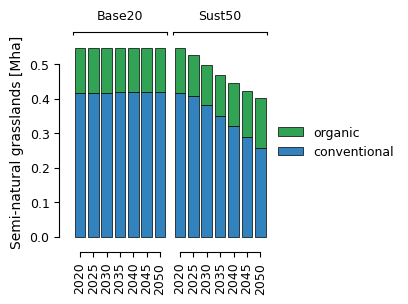

In [16]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':'land_use'})
    .loc[:,(slice(None),'semi-natural grasslands')]
    .droplevel('land_use', axis=1)
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Semi-natural grasslands [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.show()

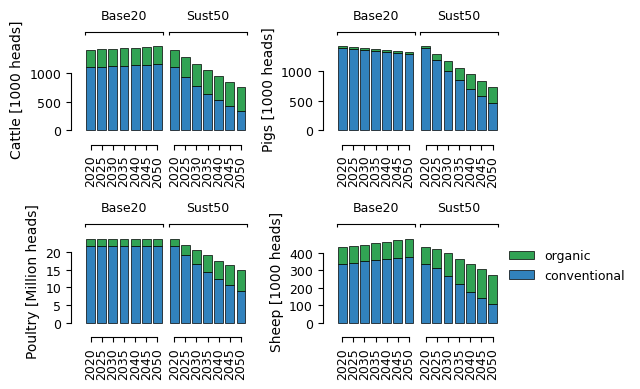

In [19]:
# Number of animal heads
plot_data = session.get_attr('A','heads',['species','prod_system'])

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(2,2, figsize=(6.5,4))

for ax,sp in zip(axs.flatten(),plot_data.drop('horses', axis=1).columns.get_level_values('species').unique()):

    cm.plot.bar(
        (plot_data / (1000000 if sp=='poultry' else 1000))
        .xs(sp, level='species', axis=1),
        **{k:v for k,v in bar_style.items() if k != 'cmap'},
        cmap=cust_cmap,
        ax=ax,
        group_levels='scn',
        ylabel=sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]')
    )

for ax in axs.flatten():
    ax.legend().set_visible(False)
ax.legend(loc='upper left', ncol=1, bbox_to_anchor=(1, 1), fontsize=9, frameon=False, reverse=True)

plt.tight_layout()
plt.show()

In [20]:
d = (
    session.get_attr('c','harvest',{'crop':['land_use',None],'prod_system':None})/
    session.get_attr('c','area',{'crop':['land_use',None],'prod_system':None})
).loc[[('Base20','2020'),('Base20','2050'),('Sust50','2050')],'cropland'] / 1_000

display(d.T.xs('conventional', level='prod_system', drop_level=False))
display(d.T.xs('organic', level='prod_system', drop_level=False))

scn                                                  Base20             \
year                                                   2020       2050   
crop                                prod_system                          
Apples                              conventional  18.327735  21.196486   
Barley, spring                      conventional   5.008140   5.969673   
Barley, winter                      conventional   6.368821   7.585723   
Beans, dry                          conventional   1.771584   1.769239   
Broad beans and horse beans, dry    conventional   3.288678   4.123441   
Buckwheat                           conventional   2.417545   1.606772   
Cabbages, cauliflowers and broccoli conventional  21.635920  27.035048   
Carrots                             conventional  67.397609  85.546520   
Cereals for fodder                  conventional   3.492761   3.496848   
Cucumbers                           conventional  61.769150   6.080621   
Currants                            conventional   1.475315   1.498246   
Energy grass                        conventional   4.026111   4.027127   
Fallow                              conventional        NaN        NaN   
Green manure                        conventional        NaN        NaN   
Herbs                               conventional   4.008428   5.097606   
Lettuce and spinach                 conventional  15.531591  19.687989   
Ley for fodder                      conventional   5.503219   5.517474   
Ley for grazing                     conventional   4.470178   4.498120   
Ley for seed                        conventional   0.650000   0.650000   
Ley not harvested                   conventional        NaN        NaN   
Maize (corn)                        conventional   6.094959   6.099353   
Maize for forage and silage         conventional  10.807726  10.766558   
Mixed cereals                       conventional   3.325805   3.298332   
Oats                                conventional   4.618543   5.749125   
Onions                              conventional  51.294697  65.026279   
Other berries                       conventional   1.675858   1.751679   
Other crops for fodder              conventional   4.329755   4.342999   
Other fruit                         conventional   4.562676   4.583998   
Other root vegetables               conventional  34.804101  43.885576   
Other vegetables                    conventional  14.883280  18.482390   
Pears                               conventional  15.632894  15.696749   
Peas, dry                           conventional   3.409491   4.265411   
Peas, green                         conventional   4.401536   4.419005   
Potatoes, starch                    conventional  45.168759  55.110546   
Potatoes, table                     conventional  38.280855  46.619571   
Pumpkins and squash                 conventional  27.154702  34.029131   
Quinoa                              conventional   1.305022   1.305022   
Rapeseed, spring                    conventional   1.835141   2.197344   
Rapeseed, winter                    conventional   3.554977   4.260119   
Rye                                 conventional   6.902539   8.623484   
Short rotation coppice              conventional   4.694050   4.693982   
Strawberries                        conventional   6.875336   6.885957   
Sugar beet                          conventional  76.494669  95.588851   
Triticale, spring                   conventional   3.302619   3.309077   
Triticale, winter                   conventional   5.751171   5.751951   
Wheat, spring                       conventional   4.628401   6.298127   
Wheat, winter                       conventional   7.246123   9.905065   

scn                                                   Sust50  
year                                                    2050  
crop                                prod_system               
Apples                              conventional   23.834540  
Barley, spring                      conventiona

scn                                              Base20                Sust50
year                                               2020       2050       2050
crop                             prod_system                                 
Apples                           organic       8.098129   8.098081   8.067687
Barley, spring                   organic       3.169379   3.266394   4.279509
Barley, winter                   organic       3.979140   4.092961   5.006794
Beans, dry                       organic       1.401542   1.695936   1.850206
Broad beans and horse beans, dry organic       2.469608   2.876244   3.406834
Buckwheat                        organic       0.911189   0.926141   0.825387
Carrots                          organic      58.610672  74.496001  80.487691
Cereals for fodder               organic       3.084835   3.082042   3.129949
Cucumbers                        organic      10.478496  13.306573  14.432907
Energy grass                     organic       3.572807   3.567817   3.689837
Fallow                           organic            NaN        NaN        NaN
Green manure                     organic            NaN        NaN        NaN
Herbs                            organic       0.869634   1.107033   1.201977
Lettuce and spinach              organic       5.836583   7.414804   8.037412
Ley for fodder                   organic       4.729565   4.733754   4.797109
Ley for grazing                  organic       3.823356   3.839384   3.898193
Ley for seed                     organic       0.400000   0.400000   0.400000
Ley not harvested                organic            NaN        NaN        NaN
Maize (corn)                     organic       3.910474   3.909678   3.882197
Mixed cereals                    organic       2.693083   2.718674   3.052535
Oats                             organic       3.039138   3.148998   3.943594
Onions                           organic      25.811051  32.785128  35.467809
Other crops for fodder           organic       3.580764   3.585242   3.602162
Other root vegetables            organic       7.241558   9.200637   9.935782
Other vegetables                 organic       3.159606   4.014594   4.282649
Pears                            organic       5.462792   5.465186   5.437654
Peas, dry                        organic       2.518303   2.933182   3.572680
Potatoes, starch                 organic            NaN        NaN  40.518832
Potatoes, table                  organic      26.032358  31.938293  35.359031
Rapeseed, spring                 organic       0.708356   0.940298   1.143416
Rapeseed, winter                 organic       2.136516   2.828225   3.358293
Rye                              organic       3.866246   5.426432   5.954733
Short rotation coppice           organic       4.496790   4.484143   4.620830
Triticale, spring                organic       2.106261   2.107009   2.035487
Triticale, winter                organic       4.228659   4.226640   4.010702
Wheat, spring                    organic       2.913765   3.624251   4.282112
Wheat, winter                    organic       4.432619   5.526902   6.120480

scn     year
Base20  2020     0.768778
        2025     0.754430
        2030     0.741768
        2035     0.731504
        2040     0.720965
        2045     0.710221
        2050     0.701255
Sust50  2020     0.768778
        2025     3.090529
        2030     4.760582
        2035     6.209927
        2040     7.580023
        2045     8.944701
        2050    10.373298
Name: Green manure, dtype: float64

scn     year
Base20  2020    144.722930
        2025    143.403104
        2030    142.055030
        2035    140.676688
        2040    139.456637
        2045    138.350892
        2050    137.178006
Sust50  2020    144.722930
        2025    136.957404
        2030    129.691579
        2035    123.256319
        2040    117.704945
        2045    112.729507
        2050    105.520095
Name: value, dtype: float64

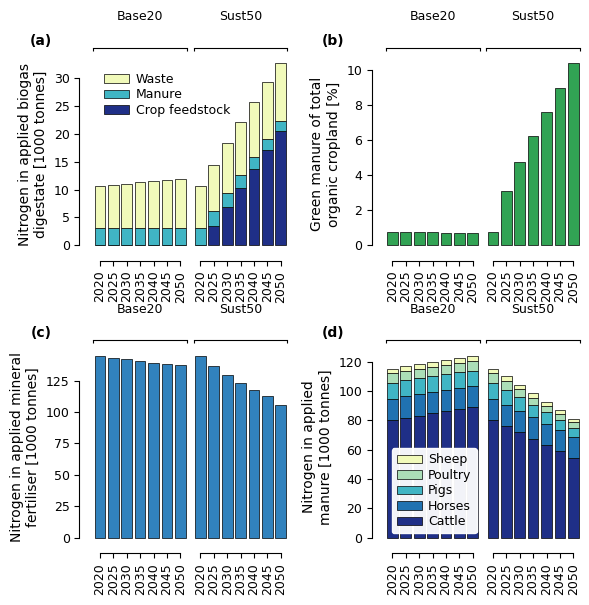

In [21]:
fig, axs = plt.subplots(2,2, figsize=(6,6))

from matplotlib.colors import ListedColormap

plot_data = (
    session.get_attr('w','organic_fertiliser_N','feedstock_type')
    .rename(columns = lambda x: 'Waste' if 'waste' in x else x.capitalize())
    .T.groupby('feedstock_type').sum().T
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied biogas\ndigestate [1000 tonnes]',
    **bar_style
)
legend = ax.legend(
    loc='upper left', bbox_to_anchor=(0, 1),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=False,
    reverse=True
)
# plt.show()

plot_data = session.get_attr('c','area',{'prod_system':None,'crop':['land_use',None]}).loc[:,('organic','cropland')].apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

colors = ['#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Green manure of total\norganic cropland [%]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
# plt.show()

display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.mineral_N','none')
)/1_000_000

colors = ['#3182bd']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied mineral\nfertiliser [1000 tonnes]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend().set_visible(False)
# plt.show()
display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.manure_N','species')
    .rename(columns = lambda x: x.capitalize())
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied\nmanure [1000 tonnes]',
    **bar_style
)
# ax.legend(loc='lower left', bbox_to_anchor=(0, 0), ncol=1, fontsize=9, frameon=True, reverse=True)
legend = ax.legend(
    loc='lower left', bbox_to_anchor=(0, 0),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=True,
    reverse=True
)
legend.get_frame().set_edgecolor('white')
# legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)
# plt.show()

plt.tight_layout()
annotate_axs(axs)
plt.savefig('figs/Fig12.png', dpi=300)
plt.show()

In [22]:
session.get_attr('c','fertiliser.mineral_N','prod_system').add(
    session.get_attr('c','fertiliser.manure_N','prod_system')+session.get_attr('c','fertiliser.organic_N','prod_system'),
    fill_value=0
)/1_000_000

prod_system  conventional    organic
scn    year                         
Base20 2020    248.446278  22.136004
       2025    248.701977  22.507172
       2030    248.786447  22.838986
       2035    248.645957  23.125771
       2040    248.748976  23.435554
       2045    249.002455  23.759845
       2050    249.002932  24.040285
Sust50 2020    248.446278  22.136004
       2025    226.644308  34.740461
       2030    206.405172  45.815562
       2035    187.752543  55.889352
       2040    170.908214  65.072948
       2045    155.511240  73.301325
       2050    142.105934  77.007508

Base20, 2020
------------


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,40.110109,0.808339,71.759587,4.671913,117.349948
Organic\ncropland,13.721916,39.229353,NaN,3.318524,56.269793


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,33.603039,0.677202,60.118016,3.913987
Organic\ncropland,24.239805,69.298769,NaN,5.862182


Sust50, 2050
------------


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,24.573889,0.092731,89.093907,0.000000,113.760527
Organic\ncropland,8.897177,25.486812,NaN,27.669604,62.053592


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,21.379225,0.080676,77.511489,0.000000
Organic\ncropland,14.070643,40.306700,NaN,43.758727


C:\Users\jnka0003\AppData\Local\Temp\ipykernel_13832\710613136.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


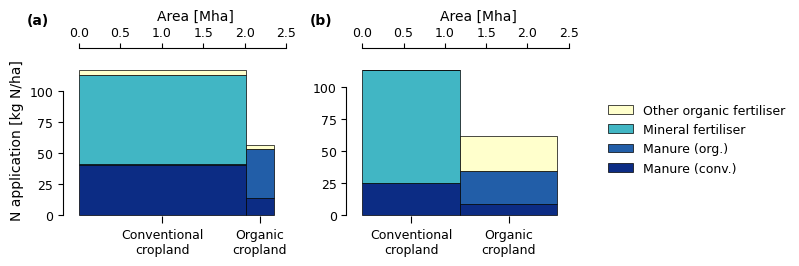

In [23]:
from matplotlib.colors import ListedColormap
colors = ['#0c2c84', '#225ea8', '#41b6c4', '#ffffcc']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(1,2, figsize=(6.7,2), gridspec_kw={'wspace' : 0.2})

i=0
for scn, year in [('Base20','2020'),('Sust50','2050')]:

    ax = axs[i]
    
    mi = (
        session.get_attr('c','fertiliser.mineral_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    ma = (
        session.get_attr('c','fertiliser.manure_N',{'crop':'land_use','prod_system':None, 'animal_prod_system':None}).loc[(scn,year),'cropland']
        .unstack()
        .rename(columns={'conventional':'Manure (conv.)', 'organic':'Manure (org.)'})
    )
    
    oo = (
        session.get_attr('c','fertiliser.organic_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    
    ar = (
        session.get_attr('c','area',{'crop':'land_use', 'prod_system':None}).loc[(scn,year),'cropland']
    )
    
    plot_data = pd.concat([
        ma.div(ar, axis=0),
        mi.div(ar, axis=0).rename('Mineral fertiliser'),
        oo.div(ar, axis=0).rename('Other organic fertiliser'),
        ar.rename('area')/1_000_000
    ], axis=1).rename(index={'conventional':'Conventional\ncropland','organic':'Organic\ncropland'})
    
    cm.plot.marimekko(
        plot_data.fillna(0),
        ax=ax,
        x_column='area',
        cmap=cust_cmap,
        sort_categories=False,
        xlim_pad = 0.2,
        ylim_pad = 0.05,
        xcategorylabels_rotation=0,
        xcategorylabels_halign='center',
        ylabel='N application [kg N/ha]' if i==0 else '',
        xlabel='Area [Mha]',
        ylabel_fontsize=10,
        xlabel_fontsize=10,
        ticklabels_fontsize=9,
        xcategorylabels_fontsize=9
    )

    if i == 1:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
    else:
        ax.legend().set_visible(False)

    table_data = plot_data.drop('area', axis=1)
    table_data['total'] = table_data.sum(axis=1)
    pstr = ', '.join((scn,year))
    print(pstr)
    print('-'*len(pstr))
    display(table_data)
    display(plot_data.div(plot_data.sum(axis=1), axis=0).drop('area', axis=1)*100)
    i += 1

plt.tight_layout()
annotate_axs(axs, offset=(-2,2.5))
plt.savefig('figs/Fig11.png', dpi=300, bbox_inches='tight')
plt.show()

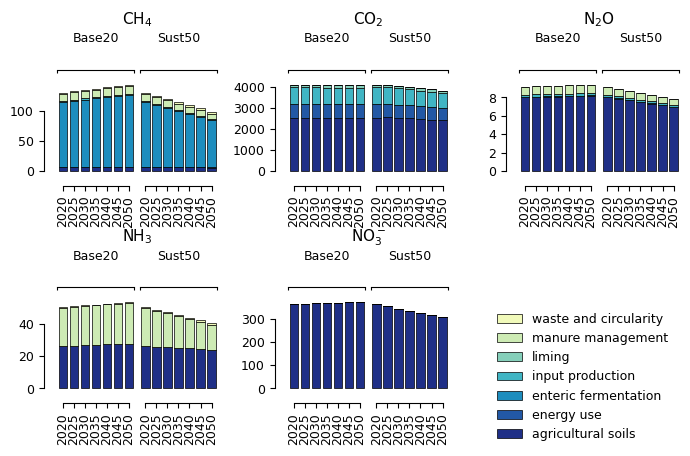

In [40]:
to_comp = {
    'CO2' : 1,
    'CH4bio' : 1,
    'CH4fos' : 1,
    'N2O' : 1,
    'N2O-N' : (44/28),
    'NH3' : 1,
    'NH3-N' : (17/14),
    'NO3-N' : (62/14),
    'NO3' : (62/14),
    'NOx' : 1,
    'NH4' : 1,
    'PO4' : 1,
    'K' : 1
}

to_comp_names = {
    'N2O' : 'N$_2$O',
    'CO2' : 'CO$_2$',
    'CH4bio' : 'CH$_4$',
    'CH4fos' : 'CH$_4$',
    'N2O-N' : 'N$_2$O',
    'NH3' : 'NH$_3$',
    'NH3-N' : 'NH$_3$',
    'NO3-N' : 'NO$_3^-$',
    'NO3' : 'NO$_3^-$',
    'NOx' : 'NO$_X$',
    'NH4' : 'NH$_4$',
    'PO4' : 'PO$_4^{3-}$',
    'K' : 'K'
}

ems = (
    cm.impact.get_emissions(session)
    .drop(['NOx-N','CO2bio','N2','NOx','K','NH4','PO4'], level='compound', axis=1)
)

plot_data = (
    ems
    .mul([to_comp[cp] for cp in ems.columns.get_level_values('compound')], axis=1)
    .rename(to_comp_names, axis=1)
    .T.groupby(['compound','process']).sum().T
    .stack().unstack().fillna(0)
)/1_000_000

fig, axs = plt.subplots(2,3, figsize=(7,4.5))
for i, cmp in enumerate(plot_data.columns.unique('compound')):
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.loc[:,cmp],
        group_levels='scn',
        ax=ax,
        **bar_style
    )
    ax.set_title(cmp, fontsize=11)

handles, labels = ax.get_legend_handles_labels()
ax = axs.flatten()[-1]
ax.legend(handles, labels, fontsize=9, frameon=False, reverse=True)
ax.axis('off')

for ax in axs.flatten()[:-1]:
    ax.legend().set_visible(False)

plt.tight_layout()
plt.savefig('figs/Fig13.png', dpi=300)
plt.show()

tab_data = plot_data.T.groupby('compound').sum().T
# tab_data['CO$_2$eq'] = tab_data.mul(pd.Series({'CO$_2$':1, 'CH$_4$':25, 'N$_2$O':298}), axis=1).sum(axis=1)
display((tab_data.div(tab_data.loc[('Base20','2020')], axis=1)*100-100).style.format(precision=0))

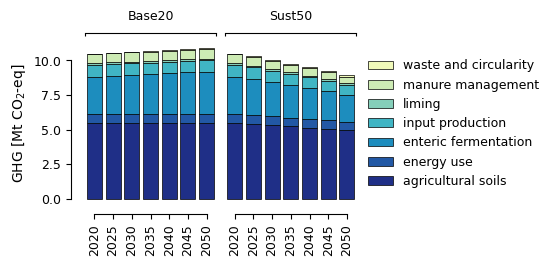

In [26]:
ghg = (
    cm.impact.get_GHG(session)
    .T.groupby('process').sum().T
) / 1_000_000_000 # [Mt]
fig, ax = plt.subplots(1,1, figsize=(3.5,2))
cm.plot.bar(
    ghg,
    group_levels='scn',
    ax=ax,
    ylabel='GHG [Mt CO$_2$-eq]',
    **bar_style
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
plt.show()

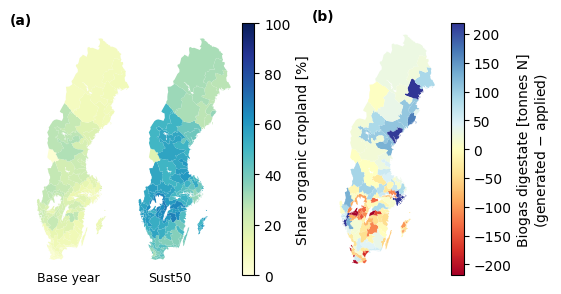

Share organic per region: 17-68%


In [27]:
plot_data1 = (
    session.get_attr('c','area',{'crop':'land_use','region':None,'prod_system':None})
    .loc[:,'cropland']
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100).xs('organic', level='prod_system')
    .droplevel(0).T
)

fig, axs = plt.subplots(1,3, figsize=(5.5,3), gridspec_kw={'width_ratios' : [1,1.25, 2.2], 'wspace' : 0})

ax=axs[0]
cm.plot.map_from_series(
    plot_data1.loc[('Sust50','2020')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax,
    legend=False
)
ax.axis('off')

ax.text(0.35, 0, 'Base year', transform=ax.transAxes, 
        fontsize=9, fontweight='normal', va='top', ha='center')

ax=axs[1]
cm.plot.map_from_series(
    plot_data1.loc[('Sust50','2050')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax,
    legend=False
)
ax.axis('off')

ax.text(0.35, 0, 'Sust50', transform=ax.transAxes, 
        fontsize=9, fontweight='normal', va='top', ha='center')

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Share organic cropland [%]', fontsize=10)

plot_data2 = (session.get_attr('w','organic_fertiliser_N','region').loc[('Sust50','2050')] - session.get_attr('c','fertiliser.organic_N','region').loc[('Sust50','2050')]) / 1_000

ax=axs[2]
cm.plot.map_from_series(
    plot_data2,
    ax = ax,
    cmap = 'RdYlBu',
    vmax = plot_data2.abs().quantile(0.95),
    vmin = -plot_data2.abs().quantile(0.95),
    legend = False
)
ax.axis('off')

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Biogas digestate [tonnes N]\n(generated $\minus$ applied)', fontsize=10)

plt.tight_layout()
annotate_axs(axs[[0,2]], offset=(0,0))
plt.savefig('figs/Fig14.png', dpi=300)
plt.show()

print(f"Share organic per region: {plot_data1.loc[('Sust50','2050')].min():.0f}-{plot_data1.loc[('Sust50','2050')].max():.0f}%")

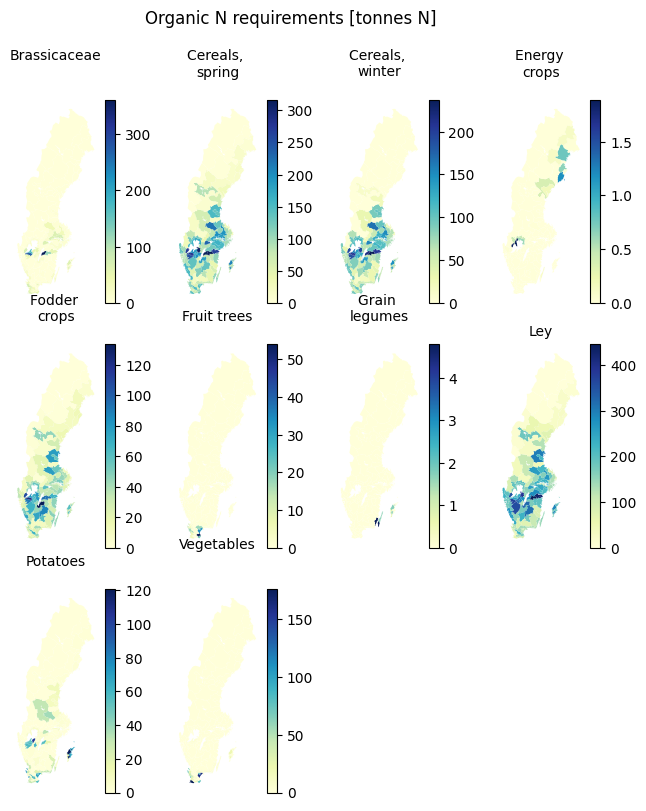

In [28]:
plot_data = (
    session.get_attr('c','fertiliser.TAN_req',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    # .T.groupby('region')
    # .apply(lambda x: x/x.sum()*100)
    # .droplevel(0).T
)/1000

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Organic N requirements [tonnes N]')
plt.show()

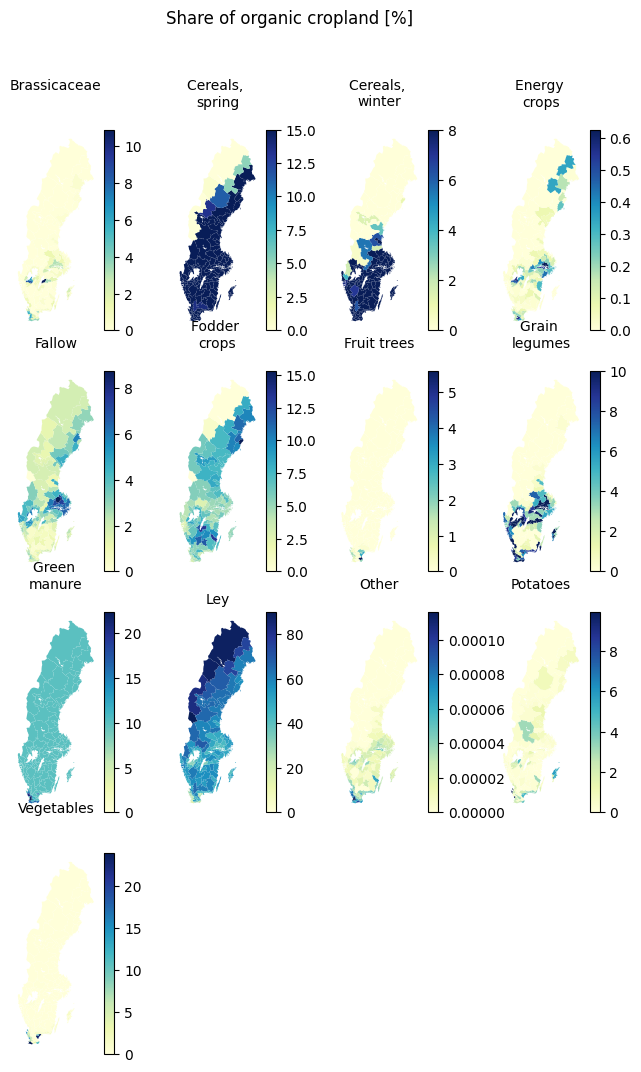

In [29]:
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100)
    .droplevel(0).T
)

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    vmin=0,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Share of organic cropland [%]')
plt.show()

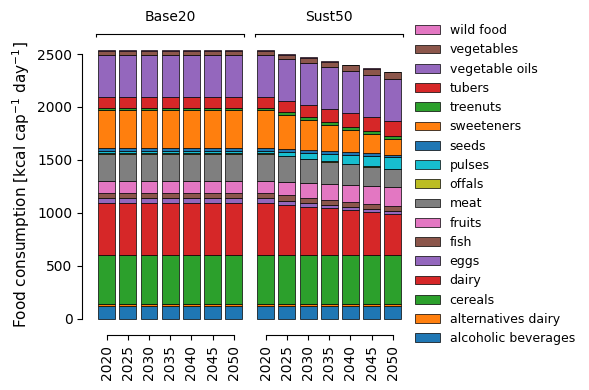

In [30]:
plot_data = (
    session.get_attr('d', 'nutrient_supply', ['nutrient','food_group'])
    .loc[:,'kcal']
    .div(
        session.get_attr('d','population')*1_000_000,
        axis=0
    )
    .div(365.25)
)

fig,ax = plt.subplots(figsize=(6,4))
cm.plot.bar(
    plot_data,
    group_levels='scn',
    ylabel='Food consumption [kcal cap$^{-1}$ day$^{-1}$]'
)

ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.tight_layout()
plt.show()

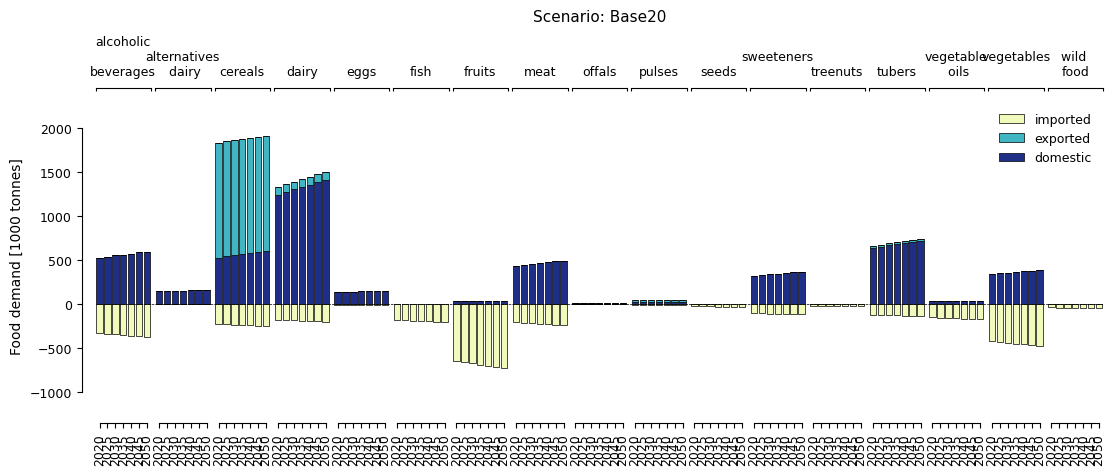

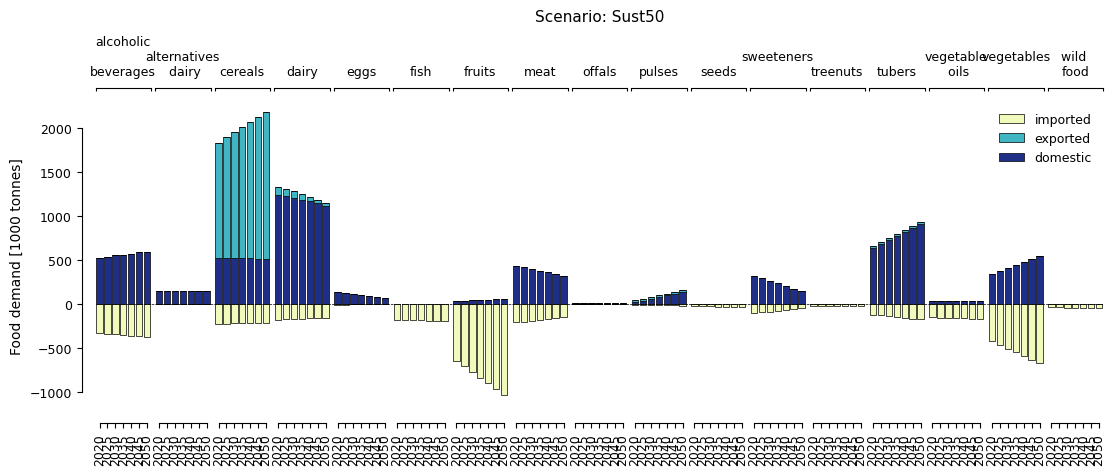

In [31]:
plot_data = (
    session.get_attr(
        module='D',
        attr='food_demand_to_processing',
        groupby=['origin','food_group']
    ).add(
        session.get_attr(
            module='D',
            attr='export_demand',
            groupby=['origin','food_group']
        ).rename(columns={'domestic':'exported'}),
        fill_value = 0
    )
    .stack()
    .fillna(0)
)/1000000
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

for scn in session.scenarios():
    fig, ax = plt.subplots(figsize=(13,4))
    cm.plot.bar(plot_data.loc[scn], group_levels='food_group', grouptitle=f'Scenario: {scn}', ax=ax,
                ylim=(-1200, 2300), totmarker='none', ylabel='Food demand [1000 tonnes]', **bar_style)
    plt.show()